In [1]:
!mkdir -p ~/.kaggle
!python kaggle.json ~/.kaggle/

The syntax of the command is incorrect.


In [2]:
!kaggle datasets download -d samuelcortinhas/apples-or-tomatoes-image-classification

Dataset URL: https://www.kaggle.com/datasets/samuelcortinhas/apples-or-tomatoes-image-classification
License(s): CC0-1.0




  0%|          | 0.00/2.33M [00:00<?, ?B/s]
 43%|████▎     | 1.00M/2.33M [00:02<00:02, 522kB/s]
 86%|████████▌ | 2.00M/2.33M [00:03<00:00, 553kB/s]
100%|██████████| 2.33M/2.33M [00:04<00:00, 577kB/s]
100%|██████████| 2.33M/2.33M [00:04<00:00, 564kB/s]


In [3]:
!unzip E:\Computer vision\Day 8\apples-or-tomatoes-image-classification.zip 

'unzip' is not recognized as an internal or external command,
operable program or batch file.


In [18]:

# re-size all the images to this
IMAGE_SIZE = [224, 224]

In [19]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img
import numpy as np
from glob import glob
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, MaxPooling2D

In [20]:

folders = glob('./train/*')
folders

['./train\\apples', './train\\tomatoes']

In [21]:
num_of_class = len(folders)
num_of_class

2

In [22]:
model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(224,224,3)))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))

model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))

model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))

model.add(Dense(64,activation='relu'))

model.add(Dense(1,activation='sigmoid'))

In [24]:
# view the structure of the model
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,177,281 (42.64 MB)

 Trainable params: 11,177,281 (42.64 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(
  loss='binary_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)

In [26]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [27]:
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

test_datagen = ImageDataGenerator(rescale = 1./255)

In [29]:
train_path = "./train"
training_set = train_datagen.flow_from_directory(train_path,
                                                 target_size = (224, 224),
                                                 batch_size = 32,
                                                 class_mode = 'binary')

Found 294 images belonging to 2 classes.


In [30]:
valid_path = "./test"
test_set = test_datagen.flow_from_directory(valid_path,
                                            target_size = (224, 224),
                                            batch_size = 32,
                                            class_mode = 'binary')

Found 97 images belonging to 2 classes.


In [31]:
history = model.fit(
  training_set,
  validation_data=test_set,
  epochs=20,
  steps_per_epoch=len(training_set),
  validation_steps=len(test_set)
)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.4966 - loss: 0.9660 - val_accuracy: 0.6495 - val_loss: 0.6546
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.6224 - loss: 0.6603 - val_accuracy: 0.6186 - val_loss: 0.6256
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.6565 - loss: 0.6294 - val_accuracy: 0.4948 - val_loss: 0.7193
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.6633 - loss: 0.6187 - val_accuracy: 0.6701 - val_loss: 0.5987
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.7143 - loss: 0.5597 - val_accuracy: 0.6907 - val_loss: 0.5221
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.7075 - loss: 0.5514 - val_accuracy: 0.6907 - val_loss: 0.6160
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.6905 - loss: 0.5839 - val_accuracy: 0.7629 - val_loss: 0.5394
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.7721 - loss: 0.5277 - val_accuracy: 0.7216 - val_loss:

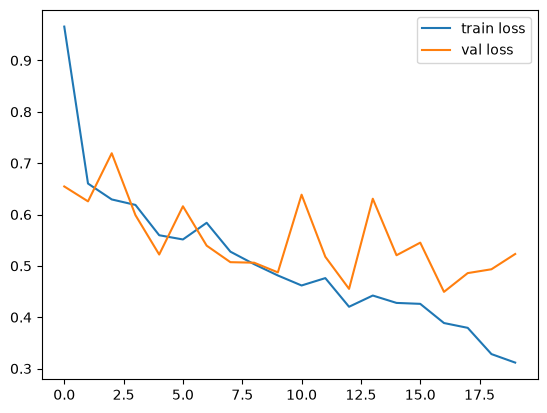

<Figure size 640x480 with 0 Axes>

In [32]:
import matplotlib.pyplot as plt
# plot the loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()
plt.savefig('LossVal_loss')

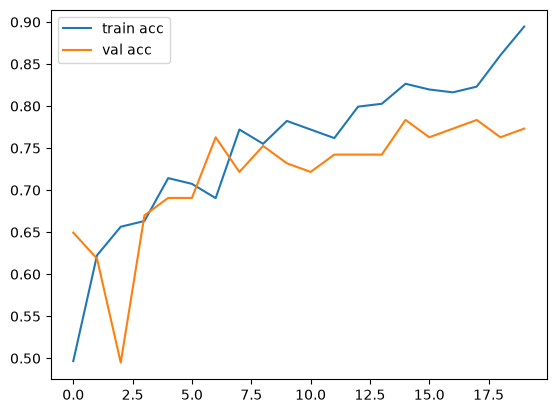

<Figure size 640x480 with 0 Axes>

In [33]:
# plot the accuracy
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()
plt.savefig('AccVal_acc')
     

In [34]:

model.evaluate(test_set)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 283ms/step - accuracy: 0.7732 - loss: 0.5231


[0.5231077671051025, 0.7731958627700806]

In [35]:
model.save('model.h5')

In [36]:
from tensorflow.keras.models import load_model

In [37]:
odel = load_model("model.h5")

In [38]:
from tensorflow.keras.preprocessing import image

In [42]:
img=image.load_img('./apple.jpeg',target_size=(224,224))     

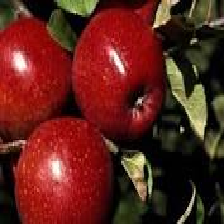

In [43]:
img

In [ ]:
import numpy as np    

In [46]:
x=image.img_to_array(img)
x=x/255

x=np.expand_dims(x,axis=0)
output = model.predict(x)
print(output)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
[[6.3317184e-06]]


In [47]:
x.shape

(1, 224, 224, 3)

In [48]:
output[0][0]

np.float32(6.3317184e-06)

In [49]:
if output[0][0] >=0.5:
    prediction = 'Tomato'
    print(prediction)
else:
    prediction = 'Apple'
    print(prediction)

Apple
